In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

Using: cuda


In [5]:
class NoiseScheduler:
    """
    Linear noise scheduler for DDPM.
    Precomputes all noise-related constants for the forward and reverse diffusion process.

    Args:
        num_timesteps : Total number of diffusion steps. Default is 1000.
        beta_start    : Starting noise level (small). Default is 0.0001.
        beta_end      : Ending noise level (large). Default is 0.02.
        device        : Device to store tensors on (cpu or cuda).
    """
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cuda'):
        self.num_timesteps = num_timesteps

        # beta: how much noise to add at each step (linearly increases)
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)

        # alpha: how much signal remains at each step
        self.alphas = 1 - self.betas

        # alpha_bar: cumulative product of alphas (how much signal remains overall)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x, t):
        """
        Forward process — adds noise to a clean image at timestep t.

        Args:
            x : Clean image tensor. Shape: (B, 1, 28, 28)
            t : Timestep indices. Shape: (B,)

        Returns:
            noisy_x : Noisy image at timestep t. Shape: (B, 1, 28, 28)
            noise   : The actual noise that was added. Shape: (B, 1, 28, 28)
        """
        noise = torch.randn_like(x)
        alpha_bar = self.alpha_bars[t].view(-1, 1, 1, 1)  # reshape for broadcasting
        noisy_x = torch.sqrt(alpha_bar) * x + torch.sqrt(1 - alpha_bar) * noise
        return noisy_x, noise

# initialize the scheduler
scheduler = NoiseScheduler(device=device)
print("Beta range:", scheduler.betas[0].item(), "→", scheduler.betas[-1].item())
print("Alpha bar at t=0:", scheduler.alpha_bars[0].item())    # should be close to 1 (clean)
print("Alpha bar at t=999:", scheduler.alpha_bars[-1].item()) # should be close to 0 (pure noise)


Beta range: 9.999999747378752e-05 → 0.019999999552965164
Alpha bar at t=0: 0.9998999834060669
Alpha bar at t=999: 4.0358296246267855e-05


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.25MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 59.2kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 779kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


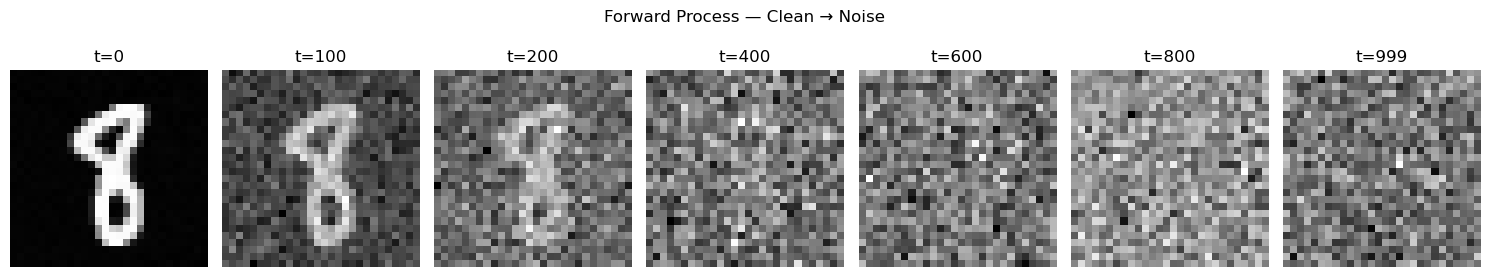

In [7]:
# load one real image to test with
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

image, _ = next(iter(loader))
image = image.to(device)

# apply noise at different timesteps and visualize
timesteps = [0, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))
for i, t in enumerate(timesteps):
    t_tensor = torch.tensor([t]).to(device)
    noisy, _ = scheduler.add_noise(image, t_tensor)
    axes[i].imshow(noisy.squeeze().cpu(), cmap='gray')
    axes[i].set_title(f't={t}')
    axes[i].axis('off')

plt.suptitle('Forward Process — Clean → Noise', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
class TimeEmbedding(nn.Module):
    """
    Sinusoidal timestep embedding — tells the U-Net which timestep it's processing.
    Same concept as positional encoding in Transformers.

    Args:
        dim : Embedding dimension size.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        """
        Args:
            t : Timestep tensor. Shape: (B,)

        Returns:
            Timestep embedding. Shape: (B, dim)
        """
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=t.device) / half
        )
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.net(embedding)


class Block(nn.Module):
    """
    Basic U-Net block — Conv → GroupNorm → SiLU + timestep conditioning.

    Args:
        in_channels  : Number of input channels.
        out_channels : Number of output channels.
        time_dim     : Timestep embedding dimension.
    """
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU()
        )
        self.time_mlp = nn.Linear(time_dim, out_channels)

    def forward(self, x, t_emb):
        """
        Args:
            x     : Feature map. Shape: (B, in_channels, H, W)
            t_emb : Timestep embedding. Shape: (B, time_dim)

        Returns:
            Feature map. Shape: (B, out_channels, H, W)
        """
        h = self.conv(x)
        t = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)  # (B, out_channels, 1, 1)
        return h + t  # inject timestep info into feature map


class UNet(nn.Module):
    """
    Simplified U-Net for DDPM noise prediction.
    Takes a noisy image and timestep, predicts the noise that was added.

    Args:
        in_channels : Number of image channels. Default 1 for grayscale.
        time_dim    : Timestep embedding dimension. Default 64.
    """
    def __init__(self, in_channels=1, time_dim=64):
        super().__init__()

        self.time_emb = TimeEmbedding(time_dim)

        # downsampling
        self.down1 = Block(in_channels, 64, time_dim)
        self.down2 = Block(64, 128, time_dim)
        self.pool = nn.MaxPool2d(2)

        # bottleneck
        self.bottleneck = Block(128, 256, time_dim)

        # upsampling
        self.up1 = Block(256 + 128, 128, time_dim)  # +128 for skip connection
        self.up2 = Block(128 + 64, 64, time_dim)    # +64 for skip connection
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # output layer — predicts noise, same shape as input image
        self.out = nn.Conv2d(64, in_channels, 1)

    def forward(self, x, t):
        """
        Args:
            x : Noisy image. Shape: (B, 1, 28, 28)
            t : Timestep indices. Shape: (B,)

        Returns:
            Predicted noise. Shape: (B, 1, 28, 28)
        """
        t_emb = self.time_emb(t)

        # downsampling + save skip connections
        d1 = self.down1(x, t_emb)        # (B, 64, 28, 28)
        d2 = self.down2(self.pool(d1), t_emb)  # (B, 128, 14, 14)

        # bottleneck
        b = self.bottleneck(self.pool(d2), t_emb)  # (B, 256, 7, 7)

        # upsampling + skip connections
        u1 = self.up1(torch.cat([self.upsample(b), d2], dim=1), t_emb)   # (B, 128, 14, 14)
        u2 = self.up2(torch.cat([self.upsample(u1), d1], dim=1), t_emb)  # (B, 64, 28, 28)

        return self.out(u2)  # (B, 1, 28, 28)


# test it
model = UNet().to(device)
x = torch.randn(4, 1, 28, 28).to(device)
t = torch.randint(0, 1000, (4,)).to(device)
out = model(x, t)
print("Input shape:", x.shape)   # (4, 1, 28, 28)
print("Output shape:", out.shape) # (4, 1, 28, 28)

Input shape: torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 1, 28, 28])


In [13]:
# data
train_loader = DataLoader(dataset, batch_size=128, shuffle=True)

# model + optimizer
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = NoiseScheduler(device=device)

epochs = 50
for epoch in range(epochs):
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)

        # sample random timesteps for each image in the batch
        t = torch.randint(0, scheduler.num_timesteps, (images.shape[0],)).to(device)

        # forward process — add noise
        noisy_images, noise = scheduler.add_noise(images, t)

        # predict the noise using U-Net
        predicted_noise = model(noisy_images, t)

        # loss — how well did we predict the noise?
        loss = nn.MSELoss()(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 1/50 | Loss: 0.0903
Epoch 2/50 | Loss: 0.0415
Epoch 3/50 | Loss: 0.0361
Epoch 4/50 | Loss: 0.0328
Epoch 5/50 | Loss: 0.0315
Epoch 6/50 | Loss: 0.0307
Epoch 7/50 | Loss: 0.0297
Epoch 8/50 | Loss: 0.0286
Epoch 9/50 | Loss: 0.0288
Epoch 10/50 | Loss: 0.0274
Epoch 11/50 | Loss: 0.0282
Epoch 12/50 | Loss: 0.0273
Epoch 13/50 | Loss: 0.0275
Epoch 14/50 | Loss: 0.0265
Epoch 15/50 | Loss: 0.0268
Epoch 16/50 | Loss: 0.0262
Epoch 17/50 | Loss: 0.0269
Epoch 18/50 | Loss: 0.0262
Epoch 19/50 | Loss: 0.0262
Epoch 20/50 | Loss: 0.0260
Epoch 21/50 | Loss: 0.0258
Epoch 22/50 | Loss: 0.0258
Epoch 23/50 | Loss: 0.0257
Epoch 24/50 | Loss: 0.0256
Epoch 25/50 | Loss: 0.0257
Epoch 26/50 | Loss: 0.0253
Epoch 27/50 | Loss: 0.0253
Epoch 28/50 | Loss: 0.0253
Epoch 29/50 | Loss: 0.0245
Epoch 30/50 | Loss: 0.0249
Epoch 31/50 | Loss: 0.0250
Epoch 32/50 | Loss: 0.0247
Epoch 33/50 | Loss: 0.0249
Epoch 34/50 | Loss: 0.0250
Epoch 35/50 | Loss: 0.0249
Epoch 36/50 | Loss: 0.0243
Epoch 37/50 | Loss: 0.0248
Epoch 38/5

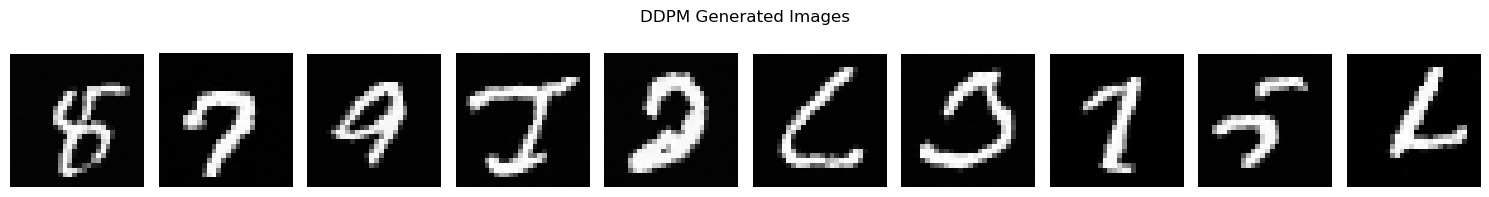

In [15]:
model.eval()

def generate(model, scheduler, n_samples=10):
    """
    Reverse process — generates images by denoising pure random noise.

    Args:
        model     : Trained U-Net model.
        scheduler : NoiseScheduler instance.
        n_samples : Number of images to generate.

    Returns:
        Generated images. Shape: (n_samples, 1, 28, 28)
    """
    with torch.no_grad():
        x = torch.randn(n_samples, 1, 28, 28).to(device)

        for t in reversed(range(scheduler.num_timesteps)):
            t_tensor = torch.full((n_samples,), t, device=device)
            predicted_noise = model(x, t_tensor)

            alpha = scheduler.alphas[t]
            alpha_bar = scheduler.alpha_bars[t]
            beta = scheduler.betas[t]

            x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * predicted_noise)

            if t > 0:
                x = x + torch.sqrt(beta) * torch.randn_like(x)

    return x.cpu()

generated = generate(model, scheduler)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('DDPM Generated Images', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
torch.save(model.state_dict(), 'ddpm_mnist.pth')
print("Model saved!")

Model saved!
